In [1]:
#Exercise 1(a)

#import modules and load the data
import pandas as pd
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from numpy import mean
from numpy import absolute


df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges,death
0,19,female,27.900,0,yes,southwest,16884.92400,0
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [ ]:
#Exercise 1(b)
#Prepare the data
df = df.dropna() #remove missings
y = df['charges'] #select Target
X = df.drop('charges',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) #Turn sex, smoker, region, and death into dummy variables

In [ ]:
#Exercise 1(c)

#Model without the sex variable
lm = LinearRegression()

Xnosex = X.drop('sex_male',axis=1) #drop the sex variable
lmscoresnc = cross_val_score(lm, Xnosex, y, #these define the type of model, features, and target
                           scoring='neg_mean_absolute_error', #test using mean absolute deviation
                           cv=5) #use cross-validation with 5 folds

#Calculate the Mean Absolute Error
lmMAEnc = mean(absolute(lmscoresnc)) #Calculate the overall mean absolute error
print('the average prediction error without sex is: %.0f' % lmMAEnc) #Print the result

the average prediction error without sex is: 4187


In [ ]:
#Exercise 2(a)
df = pd.read_csv("insurance.csv")

#With logistic regression
y= df['death']
X = df.drop('death',axis=1) #Select features
X = pd.get_dummies(X, drop_first=True) 

In [ ]:
#Exercise 2(b)
#Normalize the data
from sklearn.preprocessing import MinMaxScaler

columns = X.columns #create index with column names (needed for last step)
scaler = MinMaxScaler() #initiate the scaler
X = scaler.fit_transform(X) #scale the data
X = pd.DataFrame(X,columns=columns) #turn back into a dataframe

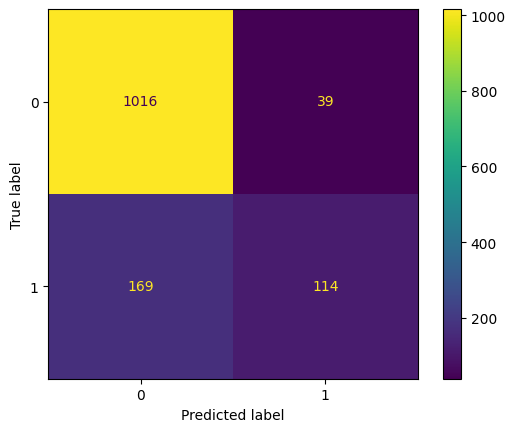

Accuracy: 0.8445440956651719
Precision: 0.7450980392156863
Recall: 0.4028268551236749
F1 Score: 0.5229357798165137


In [ ]:
#Exercise 2(c)

import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

logreg = LogisticRegression() #define the logistic regression function

y_pred = cross_val_predict(logreg, X, y, cv=5) #make the predictions

cm = confusion_matrix(y, y_pred) #create the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm) #create the graph
disp.plot() #plot the graph
plt.show() #show the graph

#calculate metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

#print the metrics
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)